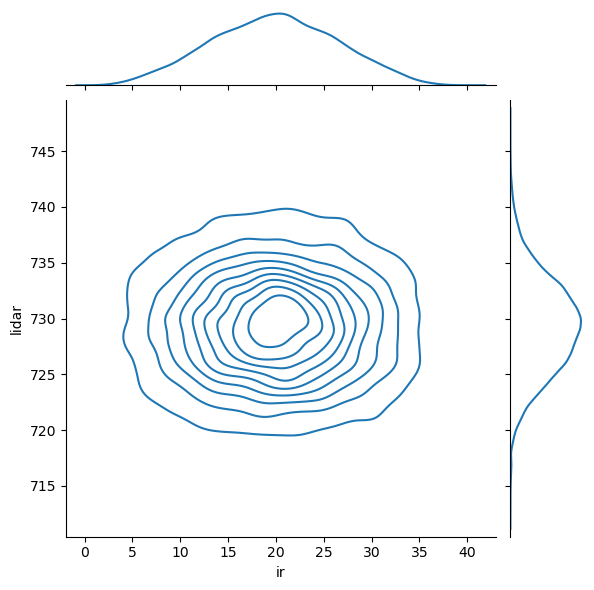

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("sensor_data_700.txt",delimiter=" ",
                   header=None, names=("deta","time","ir","lidar"))

d = data[(data["time"] < 160000) & (data["time"] >= 120000)]   #データの12時以上16時未満のデータだけ抽出
d = d.loc[:,["ir","lidar"]]     #locは取り出す行、列を指定　:は全部の行   変数.loc[行(ラベルで指定),列(ラベルで指定)]
                                #今回はdに列（"ir"と"lidar"）のすべての行を抽出
sns.jointplot(d, x="ir", y="lidar", kind="kde")
plt.show()

In [3]:
print("光センサの計測値の分散",d.ir.var())
print("LiDARの計測値の分散",d.lidar.var())

diff_ir=d.ir-d.ir.mean()
diff_lidar=d.lidar-d.lidar.mean()

a=diff_ir*diff_lidar
print("共分散：",sum(a)/(len(d)-1))

d.mean()

光センサの計測値の分散 42.117126367699505
LiDARの計測値の分散 17.702026469211596
共分散： -0.31677803385437114


ir        19.860247
lidar    729.311958
dtype: float64

In [4]:
d.cov()      #共分散を求めるメソッドcov

,ir,lidar
ir,42.117126,-0.316778
lidar,-0.316778,17.702026


In [5]:
from scipy.stats import multivariate_normal 

irlidar = multivariate_normal(mean=d.mean().values.T,cov=d.cov().values)
#.valuesで値だけ取り出したNumpy配列を.Tで転置した

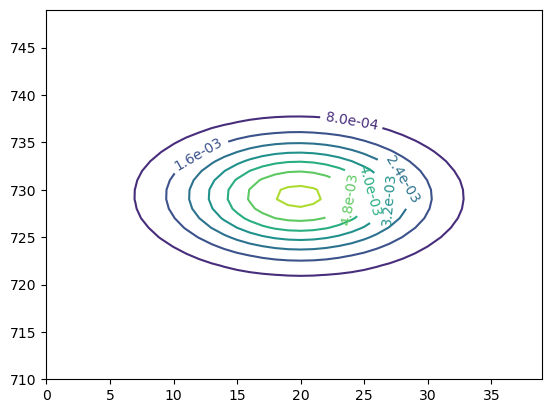

In [7]:
import numpy as np

x,y = np.mgrid[0:40,710:750]   #2次元平面に均等にXY座標を作る
pos = np.empty(x.shape+(2,))   #xは40x40の2次元リストで、これに３次元目を加えて40x40x2のリストを作成
#np.emptyで空の配列を作る　x.shapeは配列の形(0,40)  (2,)はタプルで(0,40)を(0,40,2)とする  タプルは変更できないリスト
pos[:,:,0] = x                 #配列の形は変わってほしくないのでタプルが使われる
pos[:,:,1] = y                 #加えた3次元目にx,yを代入
cont = plt.contour(x,y,irlidar.pdf(pos))   #x,y座標と、それに対応する密度を算出    plt.contourは等高線を描く
cont.clabel(fmt='%1.1e')                   #等高線に値を書き込むためのフォーマット　　clabelは等高線のラベル
#fmtはフォーマット（表示形式）　%は書式指定の開始　1.1は小数点以下一桁　eは指数表記
plt.show()

In [8]:
print("X座標：",x)
print("Y座標：",y)

X座標： [[ 0  0  0 ...  0  0  0]
 [ 1  1  1 ...  1  1  1]
 [ 2  2  2 ...  2  2  2]
 ...
 [37 37 37 ... 37 37 37]
 [38 38 38 ... 38 38 38]
 [39 39 39 ... 39 39 39]]
Y座標： [[710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]
 ...
 [710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]]


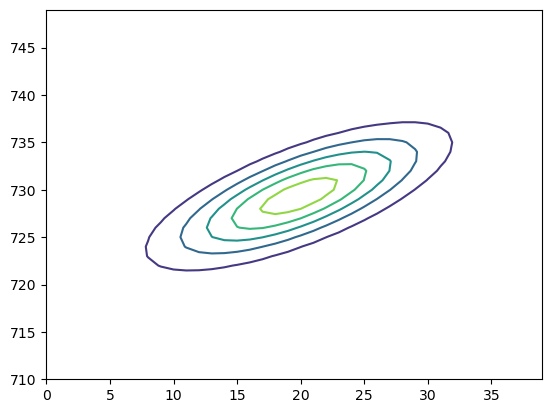

In [11]:
c = d.cov().values+np.array([[0,20],[20,0]])   
#np.arrayは行列を定義するメソッド  引数は行の数字の並びをリストにしたものをさらにリストにして行列の各要素を指定
tmp = multivariate_normal(mean=d.mean().values.T,cov=c)
cont = plt.contour(x,y,tmp.pdf(pos))
plt.show()